# 2. Exploratory Data Analysis

## Dataset Overview

### Data Source
For this analysis the result of data preparation dataframe will be used. It already have all the basic corrections done.

### Dataset Description

**Table: rest_data**

| Column | Description |
|--------|-------------|
| `id` |  Restaurant establishment unique id |
| `object_name` |  Restaurant establishment name |
| `address` | Full address of the establishment |
| `chain` | Whether the establishment is part of a chain (TRUE/FALSE) |
| `object_type` | Type of establishment (e.g., restaurant, cafe, bar) |
| `number` | Number of seats in the establishment |


## Objectives



In [9]:
# Importing necessary libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Reading cleaned data
rest_data = pd.read_csv("../data/rest_data_cleaned.csv",
                        dtype={"object_type": "category"})

In [3]:
# Checking df informations
rest_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 9648 entries, 0 to 9647
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   id           9648 non-null   int64   
 1   object_name  9648 non-null   str     
 2   address      9648 non-null   str     
 3   chain        9648 non-null   bool    
 4   object_type  9648 non-null   category
 5   number       9648 non-null   int64   
dtypes: bool(1), category(1), int64(2), str(2)
memory usage: 320.7 KB


## 2.1 Establishment type proportions

In [4]:
# Getting total number of establishments
total_estab = rest_data['object_type'].count()

In [5]:
# Group establishments by type
estab_types = rest_data['object_type'].value_counts().reset_index()

In [ ]:
# Adding proportion column
estab_types['proportion'] = estab_types['count'] / total_estab * 100

In [11]:
estab_types

,object_type,count,proportion
0,Restaurant,7253,75.176202
1,Fast Food,1066,11.048922
2,Cafe,435,4.508706
3,Pizza,319,3.306385
4,Bar,292,3.026534
5,Bakery,283,2.933250


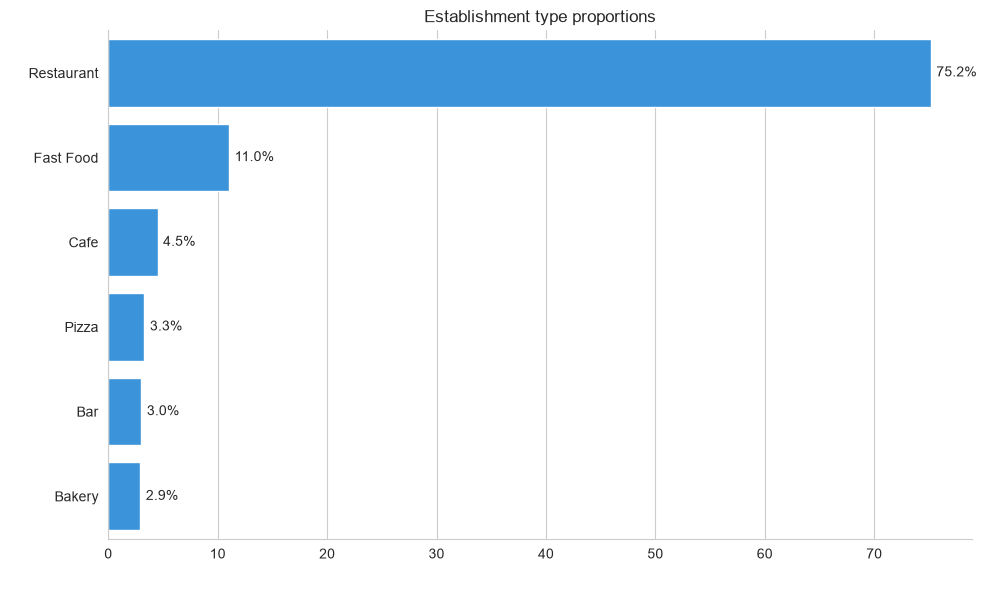

In [43]:
plt.figure(figsize=(10, 6))


ax = sns.barplot(y="object_type", x="proportion",
                 data=estab_types, order=estab_types['object_type'],
                 color="#2196F3")

for i, val in enumerate(estab_types['proportion']):
    ax.text(val + 0.5, i, f'{val:.1f}%', va='center')


ax.set_title('Establishment type proportions')
ax.set_xlabel(' ')
ax.set_ylabel(' ')

sns.despine()
plt.tight_layout()
plt.show()

### Interpretation

The bar chart reveals a **highly concentrated market** dominated by traditional restaurants:

- **Restaurants** account for **75.2%** of all establishments, making them the overwhelming majority
- **Fast Food** follows distantly with **11.0%**, the only other significant category
- Other types (**Cafes, Pizza, Bars, Bakeries**) are niche segments, each representing less than 5%

**Key Insight:** The LA market is heavily skewed towards full-service restaurants. 
This suggests that our robot-staffed cafeteria would need to differentiate itself in a market where traditional restaurants dominate. The limited presence of cafes (4.5%) indicates a potential market gap for a casual dining concept with automation.